# Importing Libraries


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Data

In [28]:
df = pd.read_csv("insurance.csv")

In [29]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Data Cleaning

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [31]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [32]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Feature Engineering

In [33]:
Male = pd.get_dummies(df['sex'], drop_first = True)
df = pd.concat([df, Male], axis = 1)
df.head()

,age,sex,bmi,children,smoker,region,charges,male
0,19,female,27.900,0,yes,southwest,16884.92400,False
1,18,male,33.770,1,no,southeast,1725.55230,True
2,28,male,33.000,3,no,southeast,4449.46200,True
3,33,male,22.705,0,no,northwest,21984.47061,True
4,32,male,28.880,0,no,northwest,3866.85520,True


In [34]:
Smoker = pd.get_dummies(df['smoker'], drop_first = True)
df = pd.concat([df, Smoker], axis = 1)
df.head()

,age,sex,bmi,children,smoker,region,charges,male,yes
0,19,female,27.900,0,yes,southwest,16884.92400,False,True
1,18,male,33.770,1,no,southeast,1725.55230,True,False
2,28,male,33.000,3,no,southeast,4449.46200,True,False
3,33,male,22.705,0,no,northwest,21984.47061,True,False
4,32,male,28.880,0,no,northwest,3866.85520,True,False


In [35]:
df = df.rename(columns = {'yes' : 'Smoker'})
df.head()

,age,sex,bmi,children,smoker,region,charges,male,Smoker
0,19,female,27.900,0,yes,southwest,16884.92400,False,True
1,18,male,33.770,1,no,southeast,1725.55230,True,False
2,28,male,33.000,3,no,southeast,4449.46200,True,False
3,33,male,22.705,0,no,northwest,21984.47061,True,False
4,32,male,28.880,0,no,northwest,3866.85520,True,False


In [15]:
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [37]:
Region = pd.get_dummies(df['region'], drop_first = True)
df = pd.concat([df, Region], axis = 1)
df.head()

,age,sex,bmi,children,smoker,region,charges,male,Smoker,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,False,True,False,False,True
1,18,male,33.770,1,no,southeast,1725.55230,True,False,False,True,False
2,28,male,33.000,3,no,southeast,4449.46200,True,False,False,True,False
3,33,male,22.705,0,no,northwest,21984.47061,True,False,True,False,False
4,32,male,28.880,0,no,northwest,3866.85520,True,False,True,False,False


# Exploratory Analysis

In [18]:
df['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

## Distribution of "Sex" Parametre

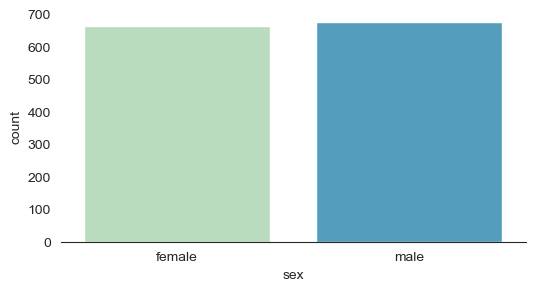

In [39]:
plt.figure(figsize = (6,3))
sns.set_style('white')
sns.countplot(x = "sex", data = df, hue = "sex" , palette = "GnBu")
sns.despine(left = True)

## Relationship of Smoking and Gender to charges 

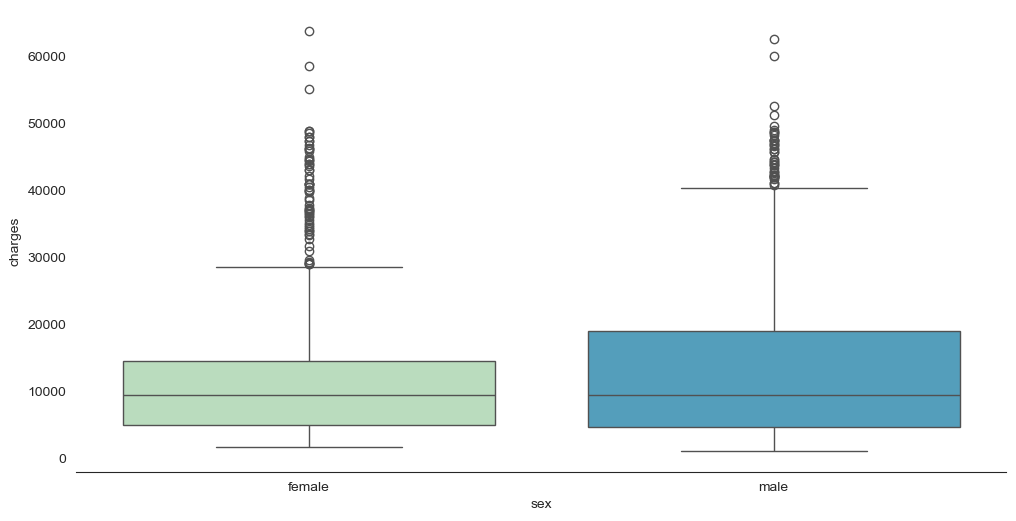

In [41]:
plt.figure(figsize = (12,6))
sns.set_style('white')
sns.boxplot(x = "sex", y = "charges", data = df, hue = "sex" , palette = "GnBu")
sns.despine(left = True)

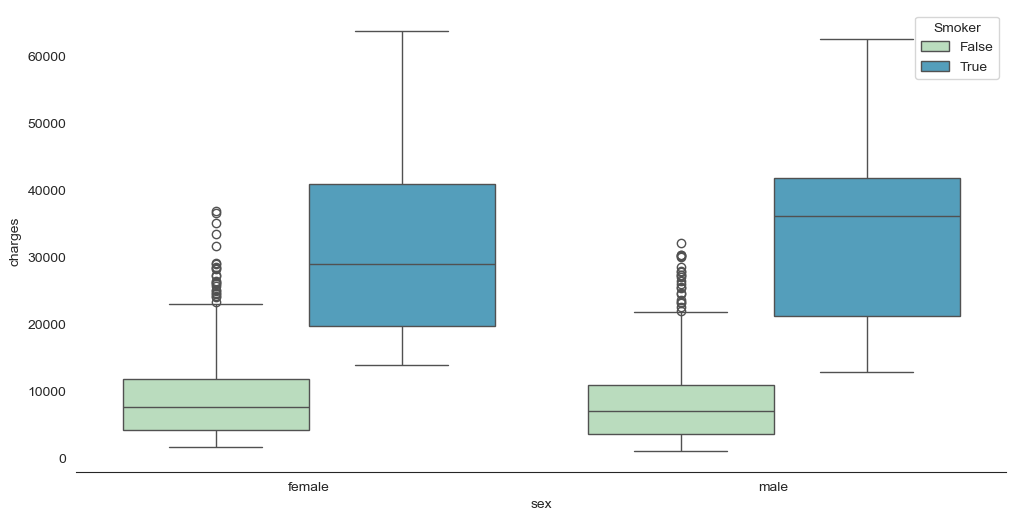

In [42]:
plt.figure(figsize = (12,6))
sns.set_style('white')
sns.boxplot(x = "sex", y = "charges", data = df, hue = "Smoker" , palette = "GnBu")
sns.despine(left = True)

<Axes: xlabel='age', ylabel='charges'>

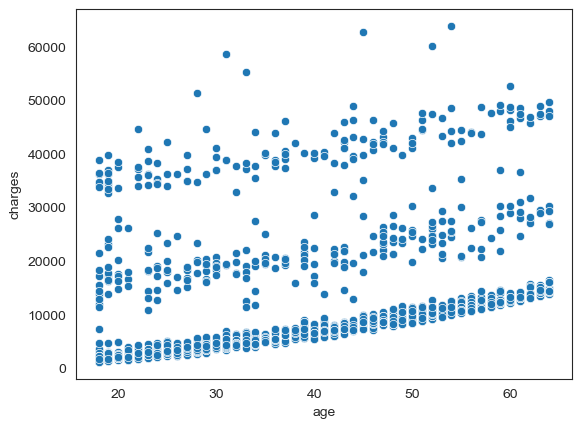

In [43]:
sns.scatterplot(x = "age", y = "charges", data = df)

<Axes: xlabel='age', ylabel='charges'>

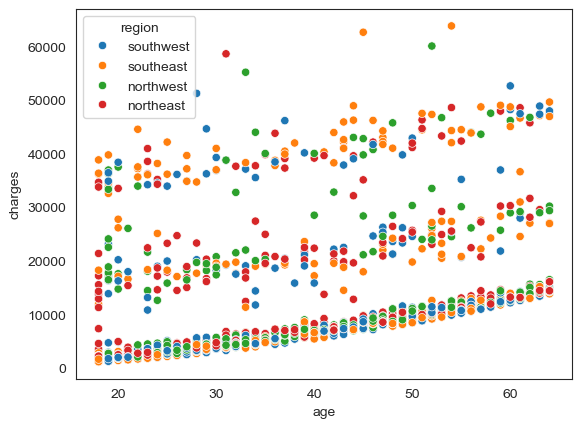

In [44]:
sns.scatterplot(x = "age", y = "charges", data = df, hue = "region")

<Axes: xlabel='age', ylabel='charges'>

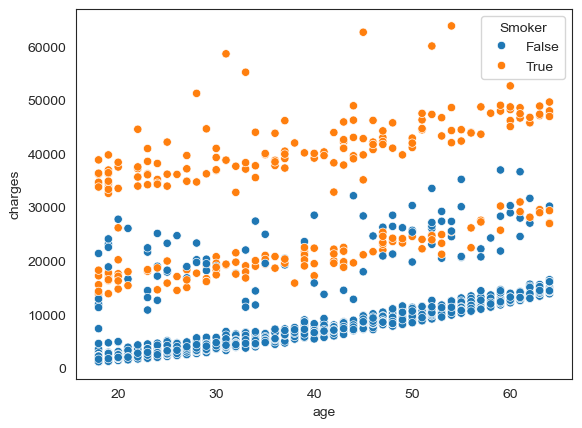

In [45]:
sns.scatterplot(x = "age", y = "charges", data = df, hue = "Smoker")

<Axes: xlabel='bmi', ylabel='charges'>

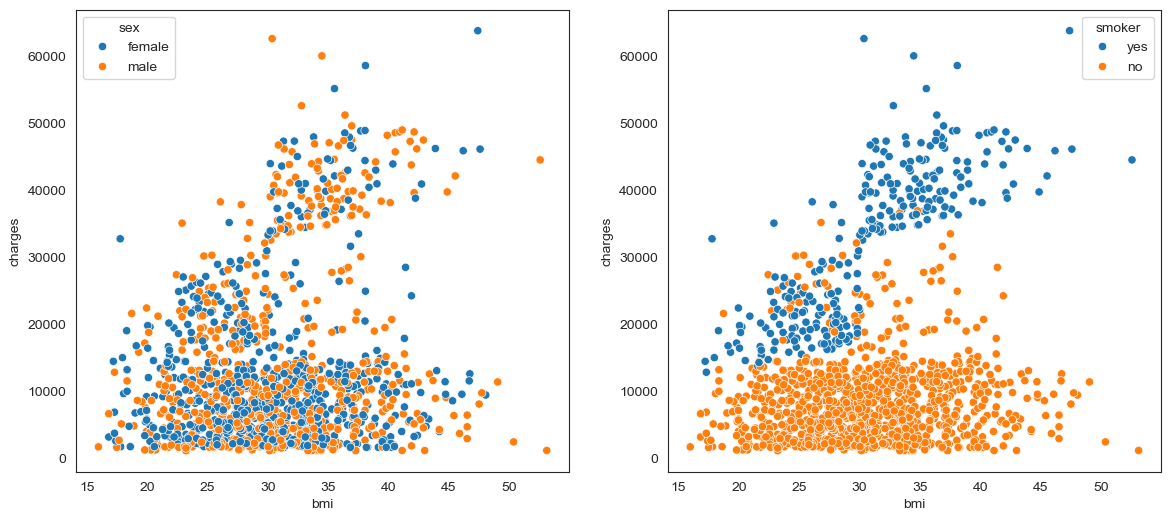

In [48]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (14,6))
sns.scatterplot(x = 'bmi', y = 'charges', data = df, hue = 'sex', ax = ax[0])
sns.scatterplot(x = 'bmi' , y = 'charges', data = df, hue = 'smoker', ax = ax[1])

<Axes: xlabel='bmi', ylabel='charges'>

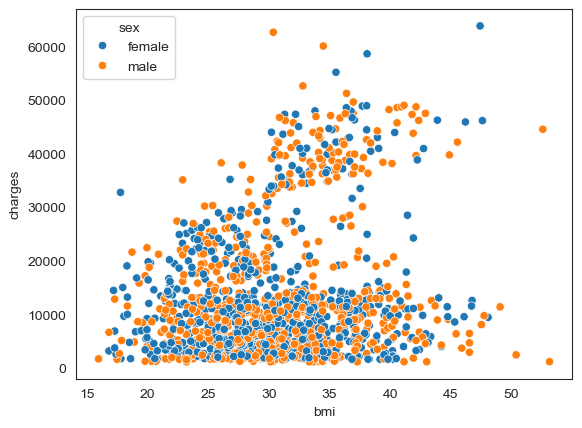

In [46]:
sns.scatterplot(x = 'bmi', y = 'charges', data = df, hue = 'sex')

<Axes: xlabel='bmi', ylabel='charges'>

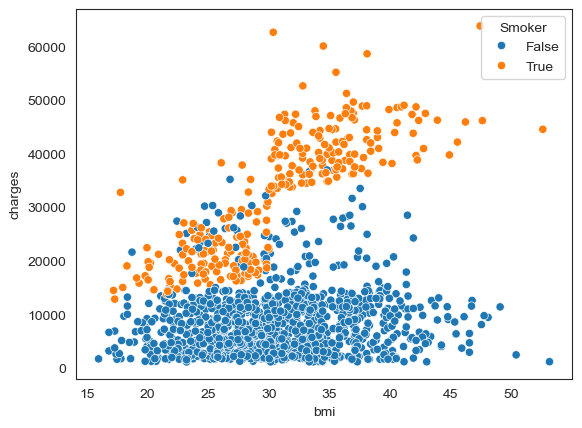

In [47]:
sns.scatterplot(x = 'bmi', y = 'charges', data = df, hue = 'Smoker')

In [49]:
df.head()

,age,sex,bmi,children,smoker,region,charges,male,Smoker,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,False,True,False,False,True
1,18,male,33.770,1,no,southeast,1725.55230,True,False,False,True,False
2,28,male,33.000,3,no,southeast,4449.46200,True,False,False,True,False
3,33,male,22.705,0,no,northwest,21984.47061,True,False,True,False,False
4,32,male,28.880,0,no,northwest,3866.85520,True,False,True,False,False


In [50]:
df.drop(["sex", "smoker", "region"], axis = 1, inplace = True)

In [51]:
df.head()

,age,bmi,children,charges,male,Smoker,northwest,southeast,southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


<Axes: >

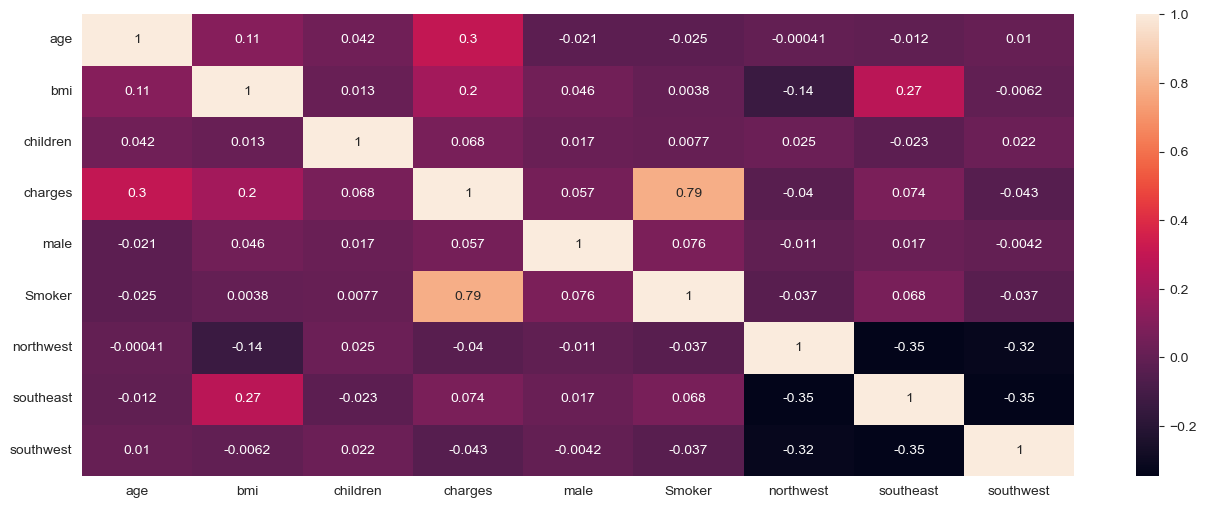

In [52]:
plt.figure(figsize = (16,6))
sns.heatmap(df.corr(), annot = True)

In [53]:
df.corr()

,age,bmi,children,charges,male,Smoker,northwest,southeast,southwest
age,1.000000,0.109272,0.042469,0.299008,-0.020856,-0.025019,-0.000407,-0.011642,0.010016
bmi,0.109272,1.000000,0.012759,0.198341,0.046371,0.003750,-0.135996,0.270025,-0.006205
children,0.042469,0.012759,1.000000,0.067998,0.017163,0.007673,0.024806,-0.023066,0.021914
charges,0.299008,0.198341,0.067998,1.000000,0.057292,0.787251,-0.039905,0.073982,-0.043210
male,-0.020856,0.046371,0.017163,0.057292,1.000000,0.076185,-0.011156,0.017117,-0.004184
Smoker,-0.025019,0.003750,0.007673,0.787251,0.076185,1.000000,-0.036945,0.068498,-0.036945
northwest,-0.000407,-0.135996,0.024806,-0.039905,-0.011156,-0.036945,1.000000,-0.346265,-0.320829
southeast,-0.011642,0.270025,-0.023066,0.073982,0.017117,0.068498,-0.346265,1.000000,-0.346265
southwest,0.010016,-0.006205,0.021914,-0.043210,-0.004184,-0.036945,-0.320829,-0.346265,1.000000


# Splitting the data

In [54]:
x = df.drop('charges', axis = 1)
y = df['charges']

In [55]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.4)

In [56]:
x_train.shape

(802, 8)

In [57]:
x_test.shape

(536, 8)

In [58]:
df.head()

,age,bmi,children,charges,male,Smoker,northwest,southeast,southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [59]:
bool_columns = ['male', 'Smoker', 'northwest', 'southeast', 'southwest']
df[bool_columns] = df[bool_columns].astype(int)

In [60]:
df.head()

,age,bmi,children,charges,male,Smoker,northwest,southeast,southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


# Scaling the data

In [62]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [72]:
scaled_x_train  = scaler.fit_transform(x_train)
scaled_x_test  = scaler.fit_transform(x_test)


In [73]:
scaled_x_train

array([[-1.01831981, -0.06149653, -0.92071124, ..., -0.5610295 ,
        -0.62060197,  1.74073282],
       [ 1.49856291, -1.00004634, -0.92071124, ..., -0.5610295 ,
         1.61133875, -0.5744707 ],
       [ 1.42665198, -0.64167591,  1.55440747, ...,  1.78243747,
        -0.62060197, -0.5744707 ],
       ...,
       [ 0.92327543,  0.44336713, -0.92071124, ..., -0.5610295 ,
        -0.62060197, -0.5744707 ],
       [ 0.70754263, -0.78320326,  0.7293679 , ...,  1.78243747,
        -0.62060197, -0.5744707 ],
       [-1.23405262, -0.89328009, -0.92071124, ...,  1.78243747,
        -0.62060197, -0.5744707 ]])

# Support Vector Regression Model


In [69]:
from sklearn.svm import SVR

regressor = SVR()
regressor.fit(scaled_x_train, y_train)

SVR()

In [74]:
predict = regressor.predict(scaled_x_test)

In [75]:
predict.shape

(536,)

In [76]:
y_test.shape

(536,)

In [77]:
predict[:10]

array([8969.89061859, 9012.90512185, 8947.09771366, 9025.59715158,
       8983.46399791, 8953.29622866, 8938.67668863, 8991.51090145,
       9016.91905656, 8999.03769129])

In [78]:
y_test[:10]

178     8823.27900
462    15230.32405
990     3378.91000
530    48675.51770
744     8827.20990
172     1694.79640
490     1748.77400
13     11090.71780
854    24106.91255
180    11735.87905
Name: charges, dtype: float64